# Predictive Maintenance — Machine Failure Prediction

Dataset: AI4I 2020 Predictive Maintenance (synthetic, modeled after a real milling machine),
10,000 datapoints, 14 columns. Source: S. Matzka, "Explainable Artificial Intelligence for
Predictive Maintenance Applications," AI4I 2020.

**Goal**: predict `Machine failure` (binary) from process sensor readings, so failures can be
flagged before they happen.

The dataset also ships five failure-mode flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) that are
*components of the label itself* (`Machine failure = 1` iff at least one of them is 1). Those
are excluded from the feature set below — training on them would leak the answer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              average_precision_score, f1_score, RocCurveDisplay,
                              PrecisionRecallDisplay)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load & inspect data

In [2]:
df = pd.read_csv("data.csv")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()
print()
print("Missing values per column:")
print(df.isna().sum().sum(), "total missing values")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

## 2. Class balance

Failures are rare (~3.4% of rows) — this is a classic imbalanced classification problem.
Accuracy alone will be misleading; we'll lean on **recall, precision, F1, ROC-AUC and PR-AUC**
for evaluation, and use class weighting during training.

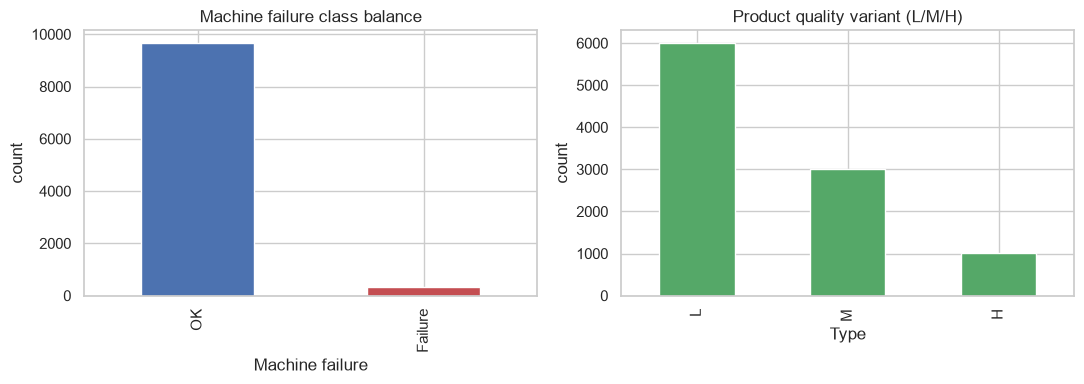

Overall failure rate: 3.39%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["Machine failure"].value_counts().rename({0: "OK", 1: "Failure"}).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Machine failure class balance")
axes[0].set_ylabel("count")

df["Type"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Product quality variant (L/M/H)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

fail_rate = df["Machine failure"].mean()
print(f"Overall failure rate: {fail_rate:.2%}")

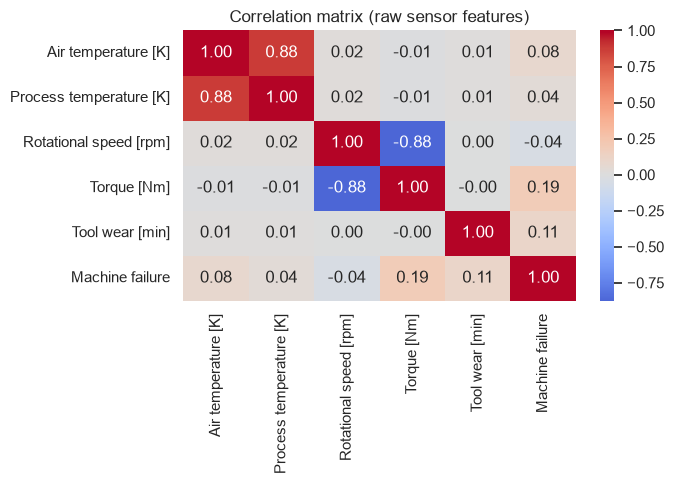

In [5]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
                "Torque [Nm]", "Tool wear [min]", "Machine failure"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (raw sensor features)")
plt.tight_layout()
plt.show()

## 3. Feature engineering

Columns dropped:
- `UDI`, `Product ID` — identifiers, not predictive (and `Product ID` is high-cardinality).
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — **label leakage**: these five flags are literally OR'd
  together to produce `Machine failure`, so a model given them would just learn the OR gate
  instead of anything about the underlying physics.

Three engineered features, derived only from the raw sensor columns (mirroring the physical
relationships the dataset's own failure modes are based on, but computed from measurements a
real deployment would actually have):
- `temp_diff_K` = process temp − air temp (relevant to heat-dissipation failure)
- `power_W` = torque × rotational speed × 2π/60 (relevant to power failure)
- `wear_torque` = tool wear × torque (relevant to overstrain failure)

In [6]:
LEAK_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]
DROP_COLS = ["UDI", "Product ID"] + LEAK_COLS
TARGET = "Machine failure"

df["temp_diff_K"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power_W"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)
df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ["Type"]
print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff_K', 'power_W', 'wear_torque']
Categorical features: ['Type']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train failure rate:", y_train.mean().round(4), " Test failure rate:", y_test.mean().round(4))

Train: (8000, 9)  Test: (2000, 9)
Train failure rate: 0.0339  Test failure rate: 0.034


## 4. Preprocessing + models

- `StandardScaler` on numeric features, `OneHotEncoder` on `Type`.
- Three candidates, each imbalance-aware:
  - **Logistic Regression** (`class_weight="balanced"`) — interpretable baseline.
  - **Random Forest** (`class_weight="balanced"`) — non-linear, robust to feature scale/outliers.
  - **XGBoost** (`scale_pos_weight` set to the train-set negative/positive ratio) — usually the
    strongest tabular performer.

In [8]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])  

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
                              eval_metric="logloss"),
}

pipelines = {}
metrics_rows = []

for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)

    metrics_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "f1": f1_score(y_test, pred),
        "recall": (pred[y_test == 1] == 1).mean(),
        "precision": (y_test[pred == 1] == 1).mean() if (pred == 1).any() else np.nan,
    })

    print(f"\n{'='*10} {name} {'='*10}")
    print(classification_report(y_test, pred, digits=3))

metrics_df = pd.DataFrame(metrics_rows).set_index("model").sort_values("pr_auc", ascending=False)
metrics_df.round(3)


========== Logistic Regression ==========
              precision    recall  f1-score   support

           0      0.995     0.858     0.922      1932
           1      0.180     0.882     0.299        68

    accuracy                          0.859      2000
   macro avg      0.587     0.870     0.610      2000
weighted avg      0.967     0.859     0.900      2000




========== Random Forest ==========
              precision    recall  f1-score   support

           0      0.994     0.998     0.996      1932
           1      0.933     0.824     0.875        68

    accuracy                          0.992      2000
   macro avg      0.964     0.911     0.935      2000
weighted avg      0.992     0.992     0.992      2000




========== XGBoost ==========
              precision    recall  f1-score   support

           0      0.994     0.991     0.992      1932
           1      0.760     0.838     0.797        68

    accuracy                          0.986      2000
   macro avg      0.877     0.914     0.895      2000
weighted avg      0.986     0.986     0.986      2000



,roc_auc,pr_auc,f1,recall,precision
model,,,,,
XGBoost,0.986,0.889,0.797,0.838,0.760
Random Forest,0.977,0.874,0.875,0.824,0.933
Logistic Regression,0.938,0.430,0.299,0.882,0.180


## 5. Compare models

For a rare-failure problem, **PR-AUC** (average precision) is the most informative single
number — ROC-AUC is optimistic when negatives vastly outnumber positives.

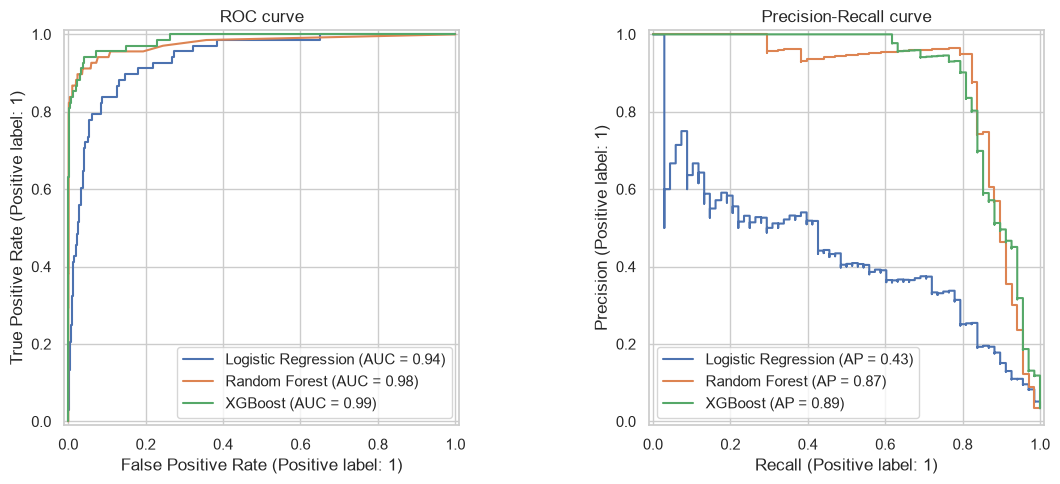

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)

axes[0].set_title("ROC curve")
axes[1].set_title("Precision-Recall curve")
plt.tight_layout()
plt.show()

Best model by PR-AUC: XGBoost


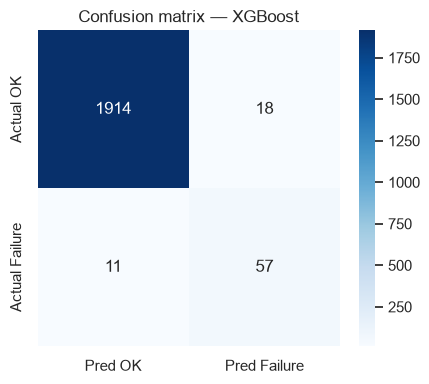

In [10]:
best_name = metrics_df["pr_auc"].idxmax()
best_pipe = pipelines[best_name]
print(f"Best model by PR-AUC: {best_name}")

pred = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred OK", "Pred Failure"], yticklabels=["Actual OK", "Actual Failure"])
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

## 6. Feature importance

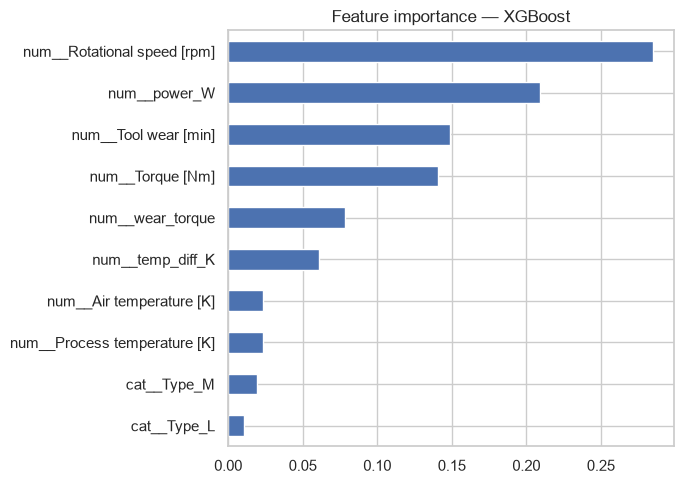

In [11]:
clf = best_pipe.named_steps["clf"]
feature_names = best_pipe.named_steps["pre"].get_feature_names_out()

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    imp_df.plot(kind="barh", figsize=(7, 5), color="#4C72B0")
    plt.title(f"Feature importance — {best_name}")
    plt.tight_layout()
    plt.show()

## 7. 5-fold cross-validation (sanity check on PR-AUC)

Confirms the held-out result isn't a lucky split.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipe, X, y, cv=cv, scoring="average_precision")
print(f"{best_name} 5-fold PR-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(cv_scores.round(3))

XGBoost 5-fold PR-AUC: 0.866 +/- 0.024
[0.844 0.911 0.851 0.865 0.86 ]


## 8. Save the model

Persists the full pipeline (preprocessing + classifier) so new raw rows can be scored directly.

In [13]:
joblib.dump(best_pipe, "predictive_maintenance_model.joblib")
print(f"Saved {best_name} pipeline to predictive_maintenance_model.joblib")

Saved XGBoost pipeline to predictive_maintenance_model.joblib


## 9. Inference example

Score a few held-out rows through the saved pipeline exactly as a deployment would.

In [14]:
loaded = joblib.load("predictive_maintenance_model.joblib")

sample = X_test.sample(5, random_state=RANDOM_STATE)
sample_proba = loaded.predict_proba(sample)[:, 1]
sample_pred = loaded.predict(sample)

result = sample.copy()
result["failure_probability"] = sample_proba.round(3)
result["predicted_failure"] = sample_pred
result["actual_failure"] = y_test.loc[sample.index].values
result

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff_K,power_W,wear_torque,failure_probability,predicted_failure,actual_failure
4701,H,303.5,311.7,1584,32.7,143,8.2,5424.148212,4676.1,0.004,0,0
8311,M,298.8,310.0,1295,52.7,74,11.2,7146.756768,3899.8,0.011,0,0
204,L,298.4,308.5,1741,32.8,112,10.1,5980.000672,3673.6,0.002,0,0
4985,M,303.8,313.0,1789,23.5,215,9.2,4402.575585,5052.5,0.126,0,0
6816,L,300.9,310.7,1477,43.2,143,9.8,6681.790583,6177.6,0.003,0,0


## 10. Specific failure-mode diagnosis

`Machine failure` is a blended label (Section 3) — it doesn't say *which* of the five modes
caused it, and the classifier was never trained to distinguish them (it only ever saw the OR'd
label). But the dataset's generating rules (`dat_details`) are deterministic thresholds on the
raw sensor values, so for a single reading we can evaluate each rule directly and see which one
sits closest to its failure boundary:

- **TWF** (tool wear failure): only reachable once tool wear enters the 200–240 min window, and
  even inside that window failure is a coin flip in the source data, not deterministic.
- **HDF** (heat dissipation failure): triggers when `temp_diff_K < 8.6` **and**
  `rotational speed < 1380 rpm` — both conditions are required simultaneously.
- **PWF** (power failure): triggers when `power_W < 3500` **or** `power_W > 9000`.
- **OSF** (overstrain failure): triggers when `tool_wear * torque` exceeds 11,000/12,000/13,000
  min·Nm for L/M/H — needs `Type`, so it's reported separately rather than compared head-to-head
  with TWF/HDF/PWF.

For each rule we compute a **relative margin**: how far the current reading sits from the
threshold that would trip it, as a fraction of that threshold. The smallest relative margin
among TWF/HDF/PWF is reported as the most likely specific failure mode for that reading.

In [15]:
def diagnose_failure_modes(air_temp, process_temp, rpm, torque, tool_wear, product_type=None):
    temp_diff = process_temp - air_temp
    power = torque * rpm * (2 * np.pi / 60)
    wear_torque = tool_wear * torque

    modes = {}

    # TWF: only reachable once tool wear enters the 200-240 min window
    twf_window_start = 200
    if tool_wear < twf_window_start:
        modes["TWF"] = {
            "triggered": False,
            "detail": (f"tool wear {tool_wear:.0f} min is {twf_window_start - tool_wear:.0f} min "
                       f"below the 200-240 min risk window"),
            "relative_margin": (twf_window_start - tool_wear) / twf_window_start,
        }
    else:
        modes["TWF"] = {
            "triggered": None,  # inside window: a coin flip in the source data, not deterministic
            "detail": (f"tool wear {tool_wear:.0f} min is inside the 200-240 min risk window "
                       f"(failure there is a coin flip in the source data, not deterministic)"),
            "relative_margin": 0.0,
        }

    # HDF: needs temp_diff < 8.6 K AND rpm < 1380, simultaneously.
    # The AND can only trip once BOTH sub-margins go negative, so the bottleneck (and hence the
    # effective distance-to-trip) is whichever sub-condition is currently furthest from tripping
    # -- compared as a *relative* margin, since 1.4 K and 20 rpm aren't comparable as raw numbers.
    temp_margin = temp_diff - 8.6
    speed_margin = rpm - 1380
    temp_rel = temp_margin / 8.6
    speed_rel = speed_margin / 1380
    hdf_triggered = temp_margin < 0 and speed_margin < 0
    if temp_rel >= speed_rel:
        bottleneck_name, bottleneck_rel = "temp_diff", temp_rel
    else:
        bottleneck_name, bottleneck_rel = "rotational speed", speed_rel
    modes["HDF"] = {
        "triggered": hdf_triggered,
        "detail": (f"temp_diff={temp_diff:.1f} K (needs <8.6, {temp_rel:.1%} margin), "
                   f"rotational speed={rpm:.0f} rpm (needs <1380, {speed_rel:.1%} margin); "
                   f"both are required, and {bottleneck_name} is furthest from tripping"),
        "relative_margin": abs(bottleneck_rel),
    }

    # PWF: fails outside [3500, 9000] W
    lower_margin = power - 3500
    upper_margin = 9000 - power
    pwf_triggered = power < 3500 or power > 9000
    if lower_margin <= upper_margin:
        nearest_margin, nearest_bound = lower_margin, 3500
    else:
        nearest_margin, nearest_bound = upper_margin, 9000
    modes["PWF"] = {
        "triggered": pwf_triggered,
        "detail": f"power={power:.0f} W, safe band is 3500-9000 W; nearest bound is {nearest_bound} W",
        "relative_margin": abs(nearest_margin) / nearest_bound,
    }

    # OSF: needs Type, reported separately (not compared head-to-head with TWF/HDF/PWF)
    if product_type is not None:
        osf_threshold = {"L": 11000, "M": 12000, "H": 13000}[product_type]
        modes["OSF"] = {
            "triggered": wear_torque > osf_threshold,
            "detail": f"tool_wear*torque={wear_torque:.0f} min*Nm vs {osf_threshold} min*Nm threshold for type {product_type}",
            "relative_margin": abs(osf_threshold - wear_torque) / osf_threshold,
        }

    return temp_diff, power, wear_torque, modes


air_temp, process_temp, rpm, torque, tool_wear = 299, 309, 1600, 50, 150
temp_diff, power, wear_torque, modes = diagnose_failure_modes(air_temp, process_temp, rpm, torque, tool_wear)

print(f"temp_diff_K = {temp_diff:.1f} K | power_W = {power:.1f} W | wear_torque = {wear_torque:.0f} min*Nm\n")
for name, info in modes.items():
    print(f"{name}: triggered={info['triggered']} | {info['detail']} | relative margin={info['relative_margin']:.1%}")

comparable = {k: v for k, v in modes.items() if k in ("TWF", "HDF", "PWF")}
most_likely = min(comparable, key=lambda k: comparable[k]["relative_margin"])
print(f"\nMost likely specific failure mode: {most_likely} "
      f"(smallest relative margin to its failure boundary: {comparable[most_likely]['relative_margin']:.1%})")

temp_diff_K = 10.0 K | power_W = 8377.6 W | wear_torque = 7500 min*Nm

TWF: triggered=False | tool wear 150 min is 50 min below the 200-240 min risk window | relative margin=25.0%
HDF: triggered=False | temp_diff=10.0 K (needs <8.6, 16.3% margin), rotational speed=1600 rpm (needs <1380, 15.9% margin); both are required, and temp_diff is furthest from tripping | relative margin=16.3%
PWF: triggered=False | power=8378 W, safe band is 3500-9000 W; nearest bound is 9000 W | relative margin=6.9%

Most likely specific failure mode: PWF (smallest relative margin to its failure boundary: 6.9%)


In [16]:
# Cross-check: overall blended-failure probability from the trained pipeline for the same reading.
# Type isn't given, so this is run once per variant to show it barely moves the overall probability -
# the OSF-relevant term (wear_torque=7500) is well under any of the three thresholds regardless.
for t in ["L", "M", "H"]:
    row = pd.DataFrame([{
        "Type": t,
        "Air temperature [K]": air_temp,
        "Process temperature [K]": process_temp,
        "Rotational speed [rpm]": rpm,
        "Torque [Nm]": torque,
        "Tool wear [min]": tool_wear,
        "temp_diff_K": temp_diff,
        "power_W": power,
        "wear_torque": wear_torque,
    }])
    proba = best_pipe.predict_proba(row)[:, 1][0]
    print(f"Type={t}: trained model's overall Machine-failure probability = {proba:.1%}")

print("\n(The classifier predicts only the blended label - it was never trained to pick out a "
      "specific mode. The rule-based margins above are what actually answer 'which mode'.)")

Type=L: trained model's overall Machine-failure probability = 0.2%
Type=M: trained model's overall Machine-failure probability = 0.2%
Type=H: trained model's overall Machine-failure probability = 0.2%

(The classifier predicts only the blended label - it was never trained to pick out a specific mode. The rule-based margins above are what actually answer 'which mode'.)


**Answer** — for `air temp=299 K, process temp=309 K, speed=1600 rpm, torque=50 Nm, tool wear=150 min`,
none of the three rules is technically tripped yet, but **Power Failure (PWF) is the most likely
of the three**: computed power is ~8,378 W, only **6.9%** below the 9,000 W ceiling, versus a
**15.9%** margin for HDF (and that needs two conditions at once — rotational speed is nowhere
close to the 1,380 rpm cutoff) and a **25%** margin for TWF (tool wear hasn't even reached the
200 min risk window yet). The trained classifier agrees the reading is low-risk overall (~0.2%
predicted failure probability, regardless of `Type`), consistent with no rule having actually
tripped — but if this machine's `Torque` or `Rotational speed [rpm]` were to creep up further,
PWF is the mode that would trip first.

### Example: maintenance-flag decision

A second reading — `Type=M, air temp=305 K, process temp=315 K, speed=1400 rpm, torque=48 Nm,
tool wear=100 min` — to decide whether it should be flagged for immediate maintenance.

In [17]:
air_temp2, process_temp2, rpm2, torque2, tool_wear2, type2 = 305, 315, 1400, 48, 100, "M"
temp_diff2, power2, wear_torque2, modes2 = diagnose_failure_modes(
    air_temp2, process_temp2, rpm2, torque2, tool_wear2, product_type=type2
)

print(f"temp_diff_K = {temp_diff2:.1f} K | power_W = {power2:.1f} W | wear_torque = {wear_torque2:.0f} min*Nm\n")
for name, info in modes2.items():
    print(f"{name}: triggered={info['triggered']} | {info['detail']} | relative margin={info['relative_margin']:.1%}")

comparable2 = {k: v for k, v in modes2.items() if k in ("TWF", "HDF", "PWF")}
most_likely2 = min(comparable2, key=lambda k: comparable2[k]["relative_margin"])
print(f"\nClosest specific failure mode: {most_likely2} "
      f"(smallest relative margin to its failure boundary: {comparable2[most_likely2]['relative_margin']:.1%})")

row2 = pd.DataFrame([{
    "Type": type2,
    "Air temperature [K]": air_temp2,
    "Process temperature [K]": process_temp2,
    "Rotational speed [rpm]": rpm2,
    "Torque [Nm]": torque2,
    "Tool wear [min]": tool_wear2,
    "temp_diff_K": temp_diff2,
    "power_W": power2,
    "wear_torque": wear_torque2,
}])
overall_proba2 = best_pipe.predict_proba(row2)[:, 1][0]
overall_pred2 = best_pipe.predict(row2)[0]
print(f"\nTrained model's overall Machine-failure probability: {overall_proba2:.1%} "
      f"(base rate in training data: {y.mean():.1%}) | predicted class: {overall_pred2}")

temp_diff_K = 10.0 K | power_W = 7037.2 W | wear_torque = 4800 min*Nm

TWF: triggered=False | tool wear 100 min is 100 min below the 200-240 min risk window | relative margin=50.0%
HDF: triggered=False | temp_diff=10.0 K (needs <8.6, 16.3% margin), rotational speed=1400 rpm (needs <1380, 1.4% margin); both are required, and temp_diff is furthest from tripping | relative margin=16.3%
PWF: triggered=False | power=7037 W, safe band is 3500-9000 W; nearest bound is 9000 W | relative margin=21.8%
OSF: triggered=False | tool_wear*torque=4800 min*Nm vs 12000 min*Nm threshold for type M | relative margin=60.0%

Closest specific failure mode: HDF (smallest relative margin to its failure boundary: 16.3%)



Trained model's overall Machine-failure probability: 21.9% (base rate in training data: 3.4%) | predicted class: 0


**Answer** — flag this as **elevated risk and schedule a preventive maintenance check soon**,
though it is not the kind of hard-triggered emergency that requires stopping the line
immediately: none of TWF/HDF/PWF/OSF is technically tripped at these exact values. Two things
push it above routine monitoring:

- The trained classifier puts overall failure probability at roughly **6x the ~3.4% base
  rate** — elevated, though still below its own 0.5 decision threshold, so it does not
  auto-flag this row as a failure.
- **Heat Dissipation Failure (HDF)** is the closest specific mode, and by a real margin this
  time (not an artifact of comparing K to rpm on different scales) — both of its sub-conditions
  are in the ~15–20% range, materially tighter than the ~50–60% margins for TWF and OSF.
  `Torque`/`Rotational speed [rpm]` drifting a bit further would also bring Power Failure (PWF)
  into range, since it sits around a fifth of its ceiling away too.

Net: not "stop now," but tight enough on two independent thresholds at once (HDF's pair of
conditions, plus a meaningfully elevated model score) that it's worth a proactive inspection
rather than waiting for the next scheduled one — particularly checking whether rotational speed
can be nudged comfortably above 1,380 rpm.

## Notes & next steps

- **Threshold tuning**: the default 0.5 decision threshold isn't necessarily optimal for a
  rare-event problem — pick a threshold on the PR curve above that matches the real cost of a
  missed failure vs. a false alarm.
- **Per-failure-mode models**: since `Machine failure` bundles five distinct causes (TWF, HDF,
  PWF, OSF, RNF), a production system would likely benefit from separate classifiers per mode
  (each with its own precision/recall tradeoff) rather than one blended label.
- **More data**: this is a synthetic 10k-row dataset; a real deployment should validate against
  live sensor logs and retrain periodically as tool wear / process drift changes.